# **Análise Exploratória de Dados**

## Informações do conjunto de dados:

## Importação das bibliotecas

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## Carregando o conjunto de dados

In [44]:
df_avaliacoes = pd.read_csv('../data/raw/avaliacoes.csv')
df_clientes = pd.read_csv('../data/raw/clientes.csv')
df_geolocalizacao = pd.read_csv('../data/raw/geolocalizacao.csv')
df_itens_pedidos = pd.read_csv('../data/raw/itens_pedidos.csv')
df_pagamentos = pd.read_csv('../data/raw/pagamentos.csv')
df_pedidos = pd.read_csv('../data/raw/pedidos.csv')
df_produtos = pd.read_csv('../data/raw/produtos.csv')
df_tabela_auxiliar = pd.read_csv('../data/raw/tabela_auxiliar.csv')
df_vendedores = pd.read_csv('../data/raw/vendedores.csv')

## Entendendo o conjunto de dados

In [45]:
def resumo_tabelas(tabelas):
    for nome, tabela in tabelas.items():
        linhas, colunas = tabela.shape
        nulos = tabela.isnull().sum()
        nulos_total = nulos.sum()
        duplicatas = tabela.duplicated().sum()

        print(f'\n{"="*150}')
        print(f'  TABELA: {nome.upper()}')
        print(f'{"="*150}')
        print(f'  Linhas      : {linhas}')
        print(f'  Colunas     : {colunas}')
        print(f'  Nulos       : {nulos_total} ({round(nulos_total / (linhas * colunas) * 100, 1)}% do total)')
        print(f'  Duplicatas  : {duplicatas} ({round(duplicatas / linhas * 100, 1)}% das linhas)')

    
        if nulos_total > 0:
            print(f'\n  Nulos por coluna:')
            for col, qtd in nulos[nulos > 0].items():
                print(f'    • {col}: {qtd} ({round(qtd / linhas * 100, 1)}%)')
    
        print(f'  Colunas     : {list(tabela.columns)}')
    
        print(f'\n  Primeiras 5 linhas:')
        display(tabela.head(5))
        print(f'  Últimas 5 linhas:')
        display(tabela.tail(5))
        print(f'  5 linhas aleatórias:')
        display(tabela.sample(5))
        print(f'  Tipos de dados:')
        display(tabela.dtypes)
        print(f'  Memória utilizada por coluna:')
        display(tabela.memory_usage(deep=True))
        print()

In [46]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
    'df_clientes': df_clientes,
    'df_geolocalizacao': df_geolocalizacao,
    'df_itens_pedidos': df_itens_pedidos,
    'df_pagamentos': df_pagamentos,
    'df_pedidos': df_pedidos,
    'df_produtos': df_produtos,
    'df_tabela_auxiliar': df_tabela_auxiliar,
    'df_vendedores': df_vendedores
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49


  5 linhas aleatórias:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
2899,655220df33262c7e0c4949a147366f94,9951,diadema,SP
127,99002261c568a84cce14d43fcffb43ea,78095,cuiaba,MT
1349,e72b4feb7abe210c52aa667abc25a3a2,3122,sao paulo,SP
2839,c8660dcf9ba70575f45d80fe28c27713,2040,sao paulo,SP
109,62760d278921b5f352461620d68a9cee,13320,salto,SP


  Tipos de dados:


seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

  Memória utilizada por coluna:


Index                        132
seller_id                 123800
seller_zip_code_prefix     24760
seller_city                56230
seller_state               30950
dtype: int64

## Tratamento dos tipos de dados|

In [47]:
df_avaliacoes = df_avaliacoes.astype({
    'review_id':'string',
    'order_id':'string',
    'review_score':'Int8',
    'review_comment_title':'string',
    'review_comment_message':'string',
})
for col in ['review_creation_date', 'review_answer_timestamp']:
    df_avaliacoes[col] = pd.to_datetime(df_avaliacoes[col])

df_clientes = df_clientes.astype({
    'customer_id':'string',
    'customer_unique_id':'string',
    'customer_zip_code_prefix':'string',
    'customer_city':'category',
    'customer_state':'category',
})


df_geolocalizacao = df_geolocalizacao.astype({
    'geolocation_zip_code_prefix':'string',
    'geolocation_lat':'float32',
    'geolocation_lng':'float32',
    'geolocation_city':'category',
    'geolocation_state':'category',
})

df_itens_pedidos = df_itens_pedidos.astype({
    'order_id':'string',
    'order_item_id':'Int64',
    'product_id':'string',
    'seller_id':'string',
    'price':'float32',
    'freight_value':'float32',
})
df_itens_pedidos['shipping_limit_date'] = pd.to_datetime(df_itens_pedidos['shipping_limit_date'])

df_pagamentos = df_pagamentos.astype({
    'order_id':'string',
    'payment_sequential':'Int8',
    'payment_type':'category',
    'payment_installments':'Int8',
    'payment_value':'float32',
})

df_pedidos = df_pedidos.astype({
    'order_id':'string',
    'customer_id':'string',
    'order_status':'category',
})
for col in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

df_produtos = df_produtos.astype({
    'product_id':'string',
    'product_category_name':'category',
    'product_name_lenght':'Int16',
    'product_description_lenght':'Int32',
    'product_photos_qty':'Int8',
    'product_weight_g':'float32',
    'product_length_cm':'float32',
    'product_height_cm':'float32',
    'product_width_cm':'float32',
})

df_tabela_auxiliar = df_tabela_auxiliar.astype({
    'product_category_name':'category',
    'product_category_name_english':'category',
})

df_vendedores = df_vendedores.astype({
    'seller_id':'string',
    'seller_zip_code_prefix':'string',
    'seller_city':'category',
    'seller_state':'category',
})

Como o objetivo é entender a relação entre notas e comentários, vamos focar na tabela de avaliações.

## Tabela de avaliações

In [48]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,<NA>,<NA>,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,<NA>,<NA>,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,<NA>,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,<NA>,<NA>,2018-07-01,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,<NA>,"meu produto chegou e ja tenho que devolver, po...",2017-07-03,2017-07-03 21:01:49


  5 linhas aleatórias:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
95219,59627354bff0f450069fae40e96b572a,2d825a962a725110b2647050cc636b3f,3,<NA>,O tamanho da carteira não estava devidamente d...,2017-12-05,2017-12-06 03:35:16
48228,ff43ec7854a895cb590a48ceffc87670,a247dd396d56ff49f7b4f4b8f9139f5c,3,<NA>,<NA>,2018-03-19,2018-03-21 23:55:19
23866,3b63e248408250d4c98008cb39dc0007,08d0b596c492f5a5041d003063f18320,5,<NA>,<NA>,2017-09-23,2017-09-25 12:43:54
8248,b1faa5c9c2a90e2e14fd38ca074cd8d0,4d9029f2c1721a0d915d363ef3473499,5,<NA>,<NA>,2018-04-10,2018-04-13 00:51:03
93084,5b9d22e95a99a78aae6042217c855133,a3d20c33ef5a2ef98d27444699be5715,5,<NA>,<NA>,2018-05-06,2018-05-10 16:16:30


  Tipos de dados:


review_id                          string
order_id                           string
review_score                         Int8
review_comment_title               string
review_comment_message             string
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

  Memória utilizada por coluna:


Index                          132
review_id                  3968960
order_id                   3968960
review_score                198448
review_comment_title        947467
review_comment_message     3671710
review_creation_date        793792
review_answer_timestamp     793792
dtype: int64

## Unindo as variáveis `review_comment_title` e `review_comment_message`

In [49]:
# unindo as variáveis `review_comment_title` e `review_comment_message` em uma nova coluna `review_comment_full`
df_avaliacoes['review_comment'] = df_avaliacoes['review_comment_title'].fillna('') + ' ' + df_avaliacoes['review_comment_message'].fillna('')

In [50]:
df_avaliacoes.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
31070,15832cfb59d8a5b8d76445c3f979c121,0a9a43ac5fe59c6c4bee2a8f9b9fcce8,5,<NA>,<NA>,2018-07-11,2018-07-14 09:38:24,
97698,0c2fe609b2876204b49b19e7f1dabed0,3611ece86e8e8c233f0700db66adf592,4,<NA>,"Excelente produto e atendimento, chegou antes ...",2017-07-11,2017-07-15 00:11:00,"Excelente produto e atendimento, chegou antes..."
70214,ec21977bbfb69b9716dad354b1353537,fd287f617bff10632a3d985e4be99f81,5,<NA>,"Excelente produto, recomendo a todos",2017-08-25,2017-08-28 18:31:20,"Excelente produto, recomendo a todos"
30994,91d8569a6bf84a431a0b18cbed49ca63,a0224d0bc0030c9226e9613d6561a7aa,4,<NA>,<NA>,2018-06-12,2018-06-21 14:41:36,
34149,40e5fbb2d750e7e413400f8995a69a9e,833ca9217bfe9bb17bcf56f645362ac6,3,<NA>,<NA>,2018-02-27,2018-03-05 16:08:33,
3889,1b444f947865b8a025fbb41f75f62110,04a0e5cbdfc606ebca72c5b78caf81fe,5,<NA>,"Gostaria que criassem uma forma de entrega, me...",2018-01-31,2018-02-06 01:45:15,"Gostaria que criassem uma forma de entrega, m..."
63344,dcc9875c27853dfffe82569b2cdcb3e0,4b5e7707371fb7f696930fc47efff1f0,5,<NA>,<NA>,2017-10-25,2017-10-26 00:49:57,
59681,c119c6c509b0c674ef92196e3bb186d2,cf61ad2218e5c14397e7c0ba7a6a50f9,5,<NA>,<NA>,2018-08-15,2018-08-16 13:00:10,
21819,8147aead73cfca94c4c9d2389ec74345,37e543508b869d9d46e5cb9eedc85cdb,5,<NA>,<NA>,2018-07-25,2018-07-27 00:34:52,
27408,4cc87b0bed50d2640538555c5cb0dc5a,612153bcf3b401012b872fc891497142,4,Boa,Serviço eficiente Ok,2018-06-06,2018-06-06 19:56:18,Boa Serviço eficiente Ok


## Removendo comentários vazios

In [51]:
df_avaliacoes_limpo = df_avaliacoes[df_avaliacoes['review_comment'] != ' ']

In [52]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
25230,93ac72f25c99a0ddf8d85e6ba92b2fdf,c5d249c736d0e3a5b29868b9c59e30fd,5,Mercadoria,"Comprei recebi no combinado nada a reclamar ,i...",2018-08-26,2018-08-27 10:41:53,Mercadoria Comprei recebi no combinado nada a...
59700,8e9898499676308977b16c0c81459f2b,992e5d6c51707533e0be958b2e283373,3,<NA>,bom,2018-01-19,2018-01-23 00:39:46,bom
7571,0fc42b14539f4177f534382d69d82d3c,5510c1adb5cc6262d2fd7ce904b6e8f4,1,<NA>,demora na entrega,2018-06-09,2018-06-09 23:19:21,demora na entrega
99200,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto enganosa,Foto muito diferente principalmente a graninha...,2018-03-28,2018-05-25 01:23:26,Foto enganosa Foto muito diferente principalm...
60993,014be4712ce86e435b89b4c3e817900b,a212cde404c8177ad20508a28c282082,5,<NA>,Muito bem embalados,2017-11-28,2017-11-29 13:39:00,Muito bem embalados
88343,4cc84ffbff1869a281ef8ffd3b0cba8f,f330860e4cc30640994fc5d022b00934,1,Descaso,"Comprei, solicitei informações e não recebi. C...",2018-05-09,2018-05-10 13:58:38,"Descaso Comprei, solicitei informações e não r..."
63184,6f47e53efeab4be95bc991fbf9d54795,9ea6d21c1c1b510f96f7917419175197,1,<NA>,"O produto demorou muito a chegar,e a vasilha d...",2018-03-02,2018-03-03 02:06:25,"O produto demorou muito a chegar,e a vasilha ..."
97041,05449fa4290d6dfbf218daf13fd21fac,3b253446924d20b4bb7220dfa7c68149,5,<NA>,Produto ótimo!!!!\r\nVeio certinho e chegou 17...,2018-04-13,2018-04-15 22:42:28,Produto ótimo!!!!\r\nVeio certinho e chegou 1...
65386,6cf7a845ce10b659cd2394dfbae4ae54,f40a640657c0a3e1eb9d081b320875b3,4,<NA>,Entrega rápida e ainda aguardando testar o pro...,2017-07-14,2017-07-15 18:07:00,Entrega rápida e ainda aguardando testar o pr...
90604,78ef188726f0bf273844e117b63e1d80,d05d5881240a2b6f02e90a83bddc85cd,1,<NA>,😡😡😡😡😡👎👎👎👎👎\r\nEmpresa sem compromisso com o cl...,2018-08-11,2018-08-11 14:06:21,😡😡😡😡😡👎👎👎👎👎\r\nEmpresa sem compromisso com o c...


## Removendo letras maiúsculas e pontuações

In [53]:
df_avaliacoes_limpo['review_comment'] = df_avaliacoes['review_comment'].str.lower()

In [54]:
import string

df_avaliacoes_limpo['review_comment'] = df_avaliacoes_limpo['review_comment'].str.translate(str.maketrans('', '', string.punctuation))

In [55]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
53168,a27b5001e1d42bacac5e37a33e7eec57,2027c6ba8a58df2e69194531ff9abfa8,5,<NA>,Produto bom e entrega rápida.,2018-08-16,2018-08-16 22:16:23,produto bom e entrega rápida
9786,8f1096242c47570cf77eafc50b5a6f81,35acd7d0da0be873dde0470893f3d5c2,4,Bom,Produto original ótimo,2018-08-21,2018-08-21 23:46:08,bom produto original ótimo
5900,34f483bf183f8b73aa2d672913bf2665,64f2e9aa85911b6a48e3d11ef05b73c7,5,<NA>,otimo,2017-12-09,2017-12-11 11:23:54,otimo
19161,ed675e72c61d33a50feb6bacae79069c,bf1f8df62b104db3de943cf23ed71435,5,<NA>,"Chegou antes do prazo de entrega, adorei e sup...",2018-06-02,2018-06-03 15:43:55,chegou antes do prazo de entrega adorei e sup...
47525,859b628a247fd164de9532ce7b2caf10,bf866aa88acb3c2595d0627c7a6bedf7,1,Péssima,"Não existe rastreamento da mercadoria, pois nã...",2018-04-29,2018-04-29 11:27:20,péssima não existe rastreamento da mercadoria ...
77827,8d73bbfc6369f31f50eb288cc0f614dd,ef0987feb7826e38ac57d833edc30db3,5,<NA>,Muito bom recomendo a todos !,2017-12-08,2017-12-09 00:18:17,muito bom recomendo a todos
6773,f2994e1da3e0402f1daa6ad79ee69f01,55fa1be4d71a86a2d97e29c2b65af3e0,5,<NA>,produto conforme o esperado,2017-07-06,2017-07-07 03:06:15,produto conforme o esperado
99091,fade356e7332606aa22776d8d553cdce,837b75362f8a7c08c85182dfd16cb72d,1,<NA>,Ainda nao recevi o produto.,2018-08-12,2018-08-12 13:51:31,ainda nao recevi o produto
39351,1e3e8e031ffa18e9f6c7ca098f110f9e,27a14f1949c308b236684c6b7732eb03,3,<NA>,Gostei bastante,2018-03-08,2018-03-10 14:47:39,gostei bastante
52733,15fa2777d5ba15537d0cfea3fc458b35,c88dcb67671acd5a7aeef76f77cc16f5,5,Jogo de cama,Excelente produto. Recomendo a todos,2018-06-17,2018-06-17 16:21:58,jogo de cama excelente produto recomendo a todos


## Removendo variáveis desnecessárias

In [56]:
avaliacoes = df_avaliacoes_limpo.copy()

avaliacoes = avaliacoes.drop(columns=['review_id', 'order_id', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'])

In [57]:
avaliacoes.sample(10)

,review_score,review_comment
86940,3,meu produto chegou no sábado dia 2511 e veio ...
18817,5,entrega muito rapida sempre que compre chega ...
19299,5,otimo produto otimo empresa de venda
59976,5,muito bom
27132,5,boa loja excelente loja
21373,1,não recebi não chegou não chegou
91154,2,prazo não foi cumprido e não tem nenhuma info...
59163,3,recomendo o correio só fez uma tentativa de en...
97907,1,o produto não foi entregue conforme o prazo e...
49857,5,adorei comprar nesta loja e vou comprar mais ...


## Distribuição das notas

In [58]:
def classificar_sentimento(score):
    if score == 5: return 'Muito Positivo'
    elif score == 4: return 'Positivo'
    elif score == 3: return 'Neutro'
    elif score == 2: return 'Negativo'
    else: return 'Muito Negativo'

avaliacoes['review_label'] = avaliacoes['review_score'].apply(classificar_sentimento)
display(avaliacoes.head(10))

,review_score,review_comment,review_label
3,5,recebi bem antes do prazo estipulado,Muito Positivo
4,5,parabéns lojas lannister adorei comprar pela ...,Muito Positivo
9,4,recomendo aparelho eficiente no site a marca d...,Positivo
12,4,mas um pouco travandopelo valor ta boa\r\n,Positivo
15,5,super recomendo vendedor confiável produto ok ...,Muito Positivo
16,2,gostaria de saber o que houve sempre recebi e...,Negativo
19,1,não chegou meu produto péssimo,Muito Negativo
22,5,ótimo loja nota 10,Muito Positivo
24,5,obrigado pela atençao amim dispensada,Muito Positivo
27,5,a compra foi realizada facilmente\r\na entreg...,Muito Positivo


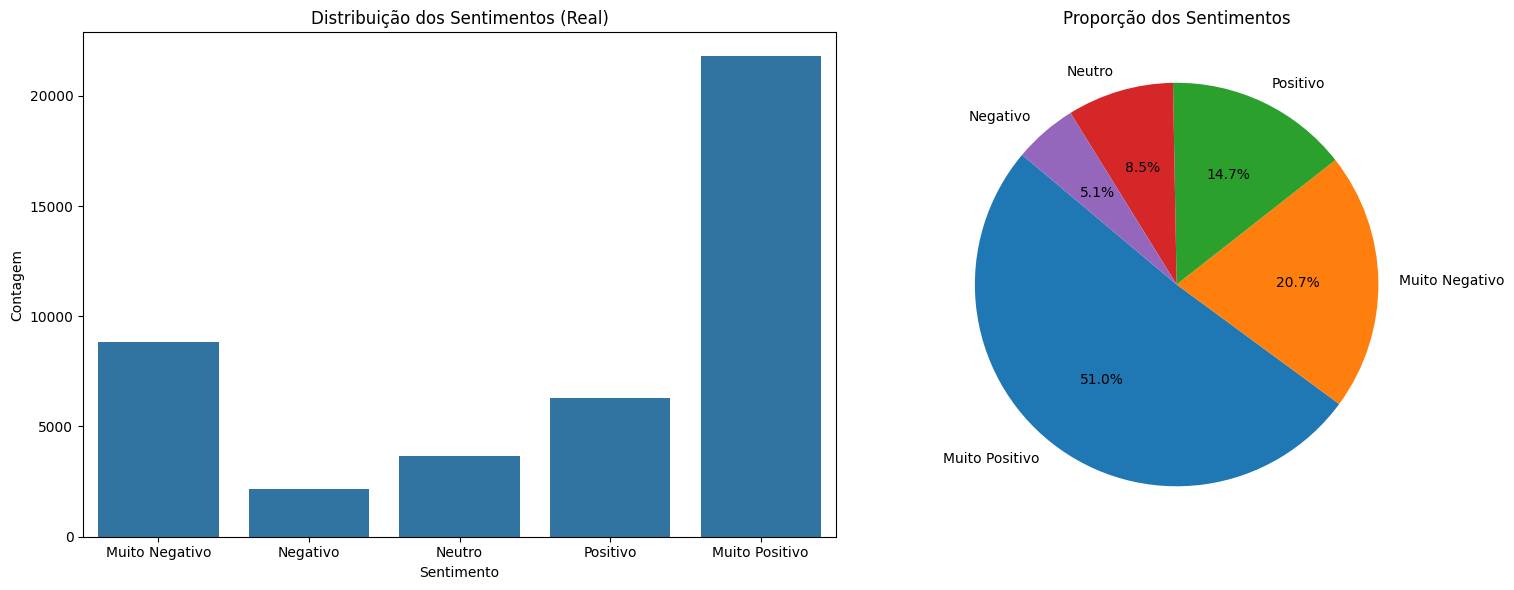

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    x='review_label',
    data=avaliacoes,
    order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'],
    ax=axes[0]
)
axes[0].set_title('Distribuição dos Sentimentos (Real)')
axes[0].set_xlabel('Sentimento')
axes[0].set_ylabel('Contagem')

axes[1].pie(
    avaliacoes['review_label'].value_counts(),
    labels=avaliacoes['review_label'].value_counts().index,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Proporção dos Sentimentos')

plt.tight_layout()
plt.show()

## Exportando o conjunto de dados

In [60]:
# avaliacoes.to_parquet("avaliacoes.parquet", index=False)